In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cryptexcode/banfakenews/LabeledAuthentic-7K.csv
/kaggle/input/datasets/cryptexcode/banfakenews/Authentic-48K.csv
/kaggle/input/datasets/cryptexcode/banfakenews/Fake-1K.csv
/kaggle/input/datasets/cryptexcode/banfakenews/LabeledFake-1K.csv


### Importing All libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

import joblib
import pickle

### Read Authentic News Dataset

In [3]:
df1 = pd.read_csv("/kaggle/input/datasets/cryptexcode/banfakenews/LabeledAuthentic-7K.csv")

In [4]:
df1.columns

Index(['articleID', 'domain', 'date', 'category', 'source', 'relation',
       'headline', 'content', 'label'],
      dtype='object')

In [5]:
df1.shape

(7202, 9)

In [6]:
df1.head(6)

,articleID,domain,date,category,source,relation,headline,content,label
0,1,bd-pratidin.com,2018-09-20 08:16:43,Sports,আফগান ক্রিকেট বোর্ড (এসিবি) প্রধান,Related,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1.0
1,2,jugantor.com,2018-09-20 20:20:20,Sports,Reporter,Related,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1.0
2,3,bd24live.com,2018-09-20 16:39:40,National,Reporter,Related,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1.0
3,4,bd24live.com,2018-09-19 18:27:56,National,জননিরাপত্তা বিভাগের সচিব,Related,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,সনাতন ধর্মাবলম্বীদের সবচেয়ে বড় ধর্মীয় উৎসব দুর...,1.0
4,5,somoynews.tv,2018-09-20 10:15:28,Finance,পেট্রোল পাম্প মালিক সমিতি সভাপতি,Related,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'",ভারত থেকে পাইপ লাইনের মাধ্যমে সরাসরি দেশে জ্বা...,1.0
5,6,samakal.com,2018-09-22 18:01:42,National,প্রধান নির্বাচন কমিশনার (সিইসি),Related,আইনগত ভিত্তি পেলেই ইভিএম ব্যবহার: সিইসি,﻿আইনগত ভিত্তি পেলেই আগামী জাতীয় সংসদ নির্বাচনে...,1.0


In [7]:
df1['label'].value_counts()

label
1.0    7202
Name: count, dtype: int64

In [8]:
df1['label'] = df1['label'].astype("int")

In [9]:
df1.head(5)

,articleID,domain,date,category,source,relation,headline,content,label
0,1,bd-pratidin.com,2018-09-20 08:16:43,Sports,আফগান ক্রিকেট বোর্ড (এসিবি) প্রধান,Related,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1
1,2,jugantor.com,2018-09-20 20:20:20,Sports,Reporter,Related,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1
2,3,bd24live.com,2018-09-20 16:39:40,National,Reporter,Related,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1
3,4,bd24live.com,2018-09-19 18:27:56,National,জননিরাপত্তা বিভাগের সচিব,Related,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,সনাতন ধর্মাবলম্বীদের সবচেয়ে বড় ধর্মীয় উৎসব দুর...,1
4,5,somoynews.tv,2018-09-20 10:15:28,Finance,পেট্রোল পাম্প মালিক সমিতি সভাপতি,Related,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'",ভারত থেকে পাইপ লাইনের মাধ্যমে সরাসরি দেশে জ্বা...,1


In [10]:
df1['content'][0]

'ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়েক বছরে তাদের পারফরম্যান্স নজর কেড়েছে ক্রিকেট জগতের। এশিয়া কাপের ১৪তম আসরেও দারুণ ছন্দে আছে আফগান ক্রিকেটাররা। পাঁচবারের এশিয়া কাপ চ্যাম্পিয়ন শ্রীলঙ্কাকে হারিয়ে এরই মধ্যে সেরা চারে পৌঁছে গেছে তারা। তবে দলের এমন ভালো সময়ে হঠাৎ করেই পদত্যাগ করেন আফগান ক্রিকেট বোর্ড (এসিবি) প্রধান আতিফ মাশাল। তবে হঠাৎ কী কারণে তার এই পদত্যাগ- এ নিয়ে ওঠা প্রশ্নের জবাব দিয়েছেন আতিফ। তিনি জানান, সরকারের অন্য একটি বিশেষ পদে তাকে নিয়োগ দেওয়ার কারণেই বোর্ডের দায়িত্ব থেকে অব্যাহতি। তার পরিবর্তে এসিবির দায়িত্ব নেবেন আফগান বোর্ডের সাবেক সহ সভাপতি আজিজ উল্লাহ ফজলে।\xa0\xa0 ২০১৭ সালের জানুয়ারিতে পাঁচ বছরের জন্য আতিফকে বোর্ড প্রধান নির্বাচন করা হলেও দায়িত্বের আড়াই বছরের মাথায় দায়িত্ব থেকে অব্যাহতি দিলেন তিনি। বিডি প্রতিদিন/ ওয়াসিফ'

In [11]:
df1.columns

Index(['articleID', 'domain', 'date', 'category', 'source', 'relation',
       'headline', 'content', 'label'],
      dtype='object')

### Drop Unnecessary Columns

In [12]:
df1.drop(columns=["articleID",'domain','date', 'category', 'source', 'relation'],axis=1,inplace=True)

In [13]:
df1.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7197    False
7198    False
7199    False
7200    False
7201    False
Length: 7202, dtype: bool

In [14]:
df1.head(5)

,headline,content,label
0,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1
1,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1
2,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1
3,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,সনাতন ধর্মাবলম্বীদের সবচেয়ে বড় ধর্মীয় উৎসব দুর...,1
4,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'",ভারত থেকে পাইপ লাইনের মাধ্যমে সরাসরি দেশে জ্বা...,1


### Concat 2 string columns headline and content together

In [15]:
df1['text'] = df1['headline']+" "+df1["content"]

In [16]:
df1.head(5)

,headline,content,label,text
0,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ ক্রি...
1,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1,টস হেরে বোলিংয়ে বাংলাদেশ এশিয়া কাপের ষষ্ঠ ম্যা...
2,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1,রাজধানীতে বিশেষ অভিযানে আটক ৪৩ রাজধানীতে মাদক ...
3,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,সনাতন ধর্মাবলম্বীদের সবচেয়ে বড় ধর্মীয় উৎসব দুর...,1,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...
4,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'",ভারত থেকে পাইপ লাইনের মাধ্যমে সরাসরি দেশে জ্বা...,1,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'..."


### Take only 2 columns text and label for prediction

In [17]:
df1 = df1[["text", "label"]]

In [18]:
df1.head()

,text,label
0,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ ক্রি...,1
1,টস হেরে বোলিংয়ে বাংলাদেশ এশিয়া কাপের ষষ্ঠ ম্যা...,1
2,রাজধানীতে বিশেষ অভিযানে আটক ৪৩ রাজধানীতে মাদক ...,1
3,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,1
4,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'...",1


## Read the fake news Dataset and perform the same operation


In [19]:
df2 = pd.read_csv("/kaggle/input/datasets/cryptexcode/banfakenews/Fake-1K.csv")

In [20]:
df2.head(5)

,articleID,domain,date,category,headline,content,label
0,1,channeldhaka.news,2019-03-14T13:34:14+00:00,International,মুরগির হামলায় শেয়াল নিহত,"বাংলায় একটা প্রবাদ আছে, শেয়ালের কাছে মুরগী বর্...",0
1,2,earki.com,"সেম্বর ১৭, ২০১৮",Miscellaneous,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম,"BTV থেকে লোকজন আসছে, ইন্টারভিউ নিবে।চারজনের টি...",0
2,3,earki.com,"২০:৩৯, জানুয়ারি ১৪, ২০১৯",Miscellaneous,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...,অদ্ভুত বিরোধীদলহীনতায় ভুগছে সরকার। এ এক অন্যরক...,0
3,4,channeldhaka.news,2018-06-30T15:56:47+00:00,Sports,অবসর নেয়ার ঘোষণা দিলেন মেসি !,রাশিয়া বিশ্বকাপ নকআউট পর্বে ফ্রান্সের সাথে ৪-৩...,0
4,5,motikontho.wordpress.com,2013-03-05T21:55:45+00:00,Miscellaneous,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি...","নিজস্ব মতিবেদক‘মাদারফাকার নহে, আমি ব্রাদারফাকা...",0


In [21]:
df2.shape

(1299, 7)

In [22]:
df2.columns

Index(['articleID', 'domain', 'date', 'category', 'headline', 'content',
       'label'],
      dtype='object')

### Check DataType

In [23]:
df2["label"] = df2["label"].astype("int")

### Remove Unnecessary Columns

In [24]:
df2.drop(columns=['articleID', 'domain', 'date', 'category'],axis=1, inplace=True)

### Concat headline and content Columns Together to create a single Column

In [25]:
df2["text"] = df2["headline"]+" "+df2["content"]

### Take only text and Label Column for prediction

In [26]:
df2 = df2[["text", "label"]]

In [27]:
df2.head(5)

,text,label
0,মুরগির হামলায় শেয়াল নিহত বাংলায় একটা প্রবাদ আছ...,0
1,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম BTV থে...,0
2,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...,0
3,অবসর নেয়ার ঘোষণা দিলেন মেসি ! রাশিয়া বিশ্বকাপ ...,0
4,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি...",0


In [28]:
df2["label"].isnull().sum()

np.int64(0)

In [29]:
df2["text"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1294    False
1295    False
1296    False
1297    False
1298    False
Name: text, Length: 1299, dtype: bool

### concat or merge authentic and fake dataset Together and create a new dataset

In [30]:
df = pd.concat([df1,df2],ignore_index = True)

In [31]:
df.head(5)

,text,label
0,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ ক্রি...,1
1,টস হেরে বোলিংয়ে বাংলাদেশ এশিয়া কাপের ষষ্ঠ ম্যা...,1
2,রাজধানীতে বিশেষ অভিযানে আটক ৪৩ রাজধানীতে মাদক ...,1
3,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,1
4,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'...",1


In [32]:
df['label'].value_counts()

label
1    7202
0    1299
Name: count, dtype: int64

## Class_weight parameter for balancing dataset

In [33]:
classes = np.unique(df['label'])
weight = compute_class_weight(
    class_weight = "balanced",
    classes = classes,
    y = df['label']
)

classesweight = dict(zip(classes,weight))

## Defining Stopwords

In [34]:
additional_stopwords = {
"এইটা","ওইটা","এটা","ওটা","তাইটা","সেইটা","কেউ","কারও","কারো","তাদেরকে","আমাদেরকে","তাহলে",
"তবুও","অতএব","যদিও","কারণ","তাই","কিন্তু","বরং","অথবা","নাকি",
"খুব","অনেক","বেশি","কম","একদম","পুরো","সম্পূর্ণ","বিশেষ","প্রায়","মোটামুটি",
"আজকে","কালকে","এখনো","তখনো","এখন","তখন","আগে","পরে","মাঝে","মধ্যে",
"কিছু","কিছুটা","অনেকটা","সব","সবাই","সবগুলো","প্রত্যেক","প্রতিটি",
"মানে","আসলে","ঠিক","ঠিকই","যেমন","ধরুন","ধরা","উদাহরণ","ইত্যাদি",
"হাহা","লল","ওকে","আচ্ছা","হুম","উম","আরে","এই","ওই",
"কি","কেন","কিভাবে","কোথায়","কখন","কোন","কোনটা","কোনটি",
"করেছে","করছে","করছিল","করতে","হয়েছে","হচ্ছে","ছিল","ছিলো","আছে","ছিলাম",
"জন্য","দিকে","উপর","নিচে","ভিতরে","বাইরে","সাথে","ছাড়া","দিয়ে","নিয়ে"}


stop_words = set(stopwords.words("bengali"))
stop_words.update(additional_stopwords)

### Data Cleaning and preprocessing Function

In [35]:
#  http\S+|www\S+
# @\w+|#\w+
def preprocessing(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+',"",text)
    text = re.sub(r'@\w+|#\w+',"",text)
    text = "".join([char for char in text if "\u0980" <= char <= "\u09FF" or char.isspace()])
    text = re.sub(r'\s+', "", text).strip()
    words = text.split()
    text = [word for word in words if word not in stop_words ]
    return "".join(text)
    
    
    

In [36]:
df["clean_text"] = df["text"].apply(preprocessing)

In [37]:
df.head(5)

,text,label,clean_text
0,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ ক্রি...,1,হঠাৎআফগানক্রিকেটবোর্ডপ্রধানেরপদত্যাগক্রিকেটবিশ...
1,টস হেরে বোলিংয়ে বাংলাদেশ এশিয়া কাপের ষষ্ঠ ম্যা...,1,টসহেরেবোলিংয়েবাংলাদেশএশিয়াকাপেরষষ্ঠম্যাচেবাংলা...
2,রাজধানীতে বিশেষ অভিযানে আটক ৪৩ রাজধানীতে মাদক ...,1,রাজধানীতেবিশেষঅভিযানেআটক৪৩রাজধানীতেমাদকবিরোধীব...
3,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,1,উস্কানিরোধেনজরদারিথাকবেসামাজিকযোগাযোগমাধ্যমেসন...
4,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'...",1,যেখানেতেলআসত৭দিনেএখনতাআসবেঅতিদ্রুতভারতথেকেপাইপ...


In [38]:
X = df['clean_text']
y = df['label']

## TfidfVectorizer for creating numeric features

In [39]:
vector = TfidfVectorizer(max_features=50000,
    ngram_range=(1,2),   # Unigram + Bigram
    min_df=3,
    max_df=0.9,
    sublinear_tf=True)
X = vector.fit_transform(X)

In [40]:
y

0       1
1       1
2       1
3       1
4       1
       ..
8496    0
8497    0
8498    0
8499    0
8500    0
Name: label, Length: 8501, dtype: int64

### Divvide the dataset into Train and Test

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Train dataset using RandomForest Model and Analysing result and prediction

 Train accuracy is: 100.0 %
Test accuracy is: 92.18106995884774 %


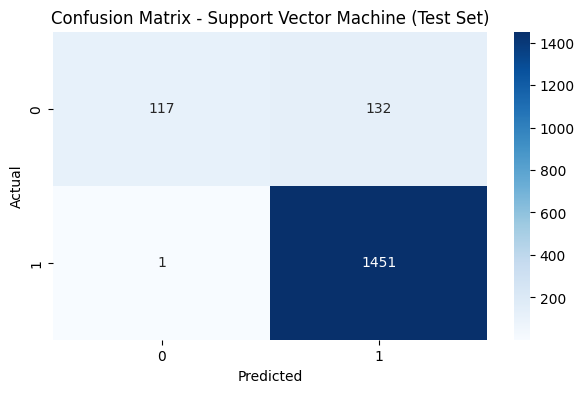

Status: Overfitting (training >> testing)


In [42]:
rf = RandomForestClassifier(class_weight= classesweight)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_train)
train_accuracy = accuracy_score(y_train,y_pred)
print(" Train accuracy is:", train_accuracy*100,"%")
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test,y_pred)
print("Test accuracy is:", test_accuracy*100,"%")
plt.figure(figsize=(7,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Support Vector Machine (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


if train_accuracy - test_accuracy > 0.05:
    print("Status: Overfitting (training >> testing)")
elif test_accuracy - train_accuracy > 0.05:
    print("Status: Underfitting (testing >> training)")
else:
    print("Status: Good Fit (training ≈ testing)")



Classification Report (Test Set):
                precision    recall  f1-score   support

Authentic News       0.87      0.84      0.85       249
     Fake News       0.97      0.98      0.98      1452

      accuracy                           0.96      1701
     macro avg       0.92      0.91      0.92      1701
  weighted avg       0.96      0.96      0.96      1701

 Train accuracy is: 99.95588235294117 %
Test accuracy is: 95.8259847148736 %


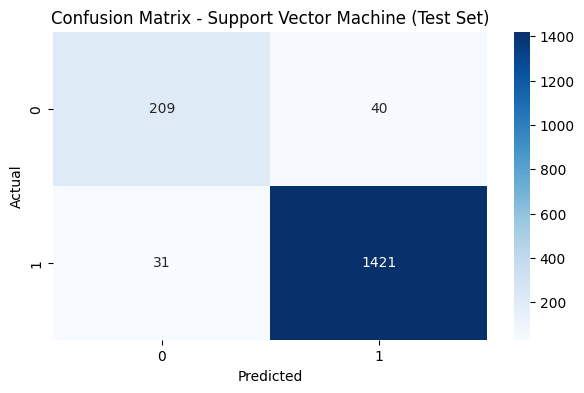

Status: Good Fit (training ≈ testing)


In [43]:
from sklearn.svm import LinearSVC

model1 = LinearSVC(class_weight= classesweight)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Authentic News', 'Fake News']))

y_pred = model1.predict(X_train)
train_accuracy = accuracy_score(y_train,y_pred)
print(" Train accuracy is:", train_accuracy*100,"%")

y_pred = model1.predict(X_test)
test_accuracy = accuracy_score(y_test,y_pred)
print("Test accuracy is:", test_accuracy*100,"%")


plt.figure(figsize=(7,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Support Vector Machine (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


if train_accuracy - test_accuracy > 0.05:
    print("Status: Overfitting (training >> testing)")
elif test_accuracy - train_accuracy > 0.05:
    print("Status: Underfitting (testing >> training)")
else:
    print("Status: Good Fit (training ≈ testing)")


### load the and numeric data of words in pkl File

In [46]:
#vector
with open("load_model.pkl", "wb") as f:
    pickle.dump(model1,f)
with open("load_vector.pkl", "wb") as f:
    pickle.dump(vector,f)